In [ ]:
# ============================================================
# Vision Transformer (ViT) - RAW (from scratch) TensorFlow/Keras
# ============================================================

!pip -q install scikit-learn

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

In [ ]:
# 1) Dataset Paths (Already split)
TRAIN_DIR = "/content/drive/MyDrive/Capstone Dataset/Guava_Fruit_Dieases/Train"
TEST_DIR  = "/content/drive/MyDrive/Capstone Dataset/Guava_Fruit_Dieases/Test"

In [ ]:
# 2) Training Config
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
EPOCHS = 30
LR = 3e-4

# ViT Config
PATCH_SIZE = 16
EMBED_DIM = 256
NUM_HEADS = 8
MLP_DIM = 512
NUM_LAYERS = 6
DROPOUT = 0.1

In [ ]:
# 3) Load Dataset (Train/Test)
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=True
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=False
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

Found 3520 files belonging to 4 classes.
Found 880 files belonging to 4 classes.
Found 880 files belonging to 4 classes.
Classes: ['Anthracnose', 'Healthy', 'Scab', 'Styler end root']


In [ ]:
# 4) Check Class Match
if val_ds.class_names != class_names:
    raise ValueError(f"Class mismatch.\nTrain: {class_names}\nTest : {val_ds.class_names}")

In [ ]:
# 5) Data Pipeline Optimization
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

In [ ]:
# 6) Data Augmentation (simple + safe)
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.2),
], name="data_augmentation")

In [ ]:
# 7) ViT Building Blocks
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dim = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dim])
        return patches

class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, embed_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(embed_dim)
        self.pos_embedding = layers.Embedding(input_dim=num_patches, output_dim=embed_dim)

    def call(self, patches):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patches) + self.pos_embedding(positions)
        return encoded

def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.nn.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

def transformer_encoder(x, embed_dim, num_heads, mlp_dim, dropout_rate):
    # LayerNorm + MultiHeadAttention
    x1 = layers.LayerNormalization(epsilon=1e-6)(x)
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(x1, x1)
    attn_output = layers.Dropout(dropout_rate)(attn_output)
    x2 = layers.Add()([x, attn_output])

    # LayerNorm + MLP
    x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
    x3 = mlp(x3, hidden_units=[mlp_dim, embed_dim], dropout_rate=dropout_rate)
    out = layers.Add()([x2, x3])
    return out

In [ ]:
# 8) Build ViT Model
num_patches = (IMG_SIZE[0] // PATCH_SIZE) * (IMG_SIZE[1] // PATCH_SIZE)

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_aug(inputs)

# ViT usually expects normalized input
x = layers.Rescaling(1./255)(x)

patches = Patches(PATCH_SIZE)(x)
encoded = PatchEncoder(num_patches, EMBED_DIM)(patches)

for _ in range(NUM_LAYERS):
    encoded = transformer_encoder(encoded, EMBED_DIM, NUM_HEADS, MLP_DIM, DROPOUT)

# Classification head
representation = layers.LayerNormalization(epsilon=1e-6)(encoded)
representation = layers.GlobalAveragePooling1D()(representation)
representation = layers.Dropout(0.3)(representation)

outputs = layers.Dense(num_classes, activation="softmax")(representation)

model = models.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ data_augmentatio… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches (Patches)   │ (None, None, 768) │          0 │ rescaling[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder       │ (None, 196, 256)  │    247,040 │ patches[0][0]     │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 196, 256)  │        512 │ patch_encoder[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 256)  │  2,103,552 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 196, 256)  │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 196, 256)  │          0 │ patch_encoder[0]… │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 256)  │        512 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 196, 512)  │    131,584 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 196, 512)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 196, 256)  │    131,328 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 196, 256)  │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 196, 256)  │          0 │ add[0][0],        │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 256)  │        512 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 256)  │  2,103,552 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 196, 256)  │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 196, 256)  │          0 │ add_1[0][0],      │
│                     │                   │            │ dropout_5[0][0] 

 Total params: 14,453,508 (55.14 MB)

 Trainable params: 14,453,508 (55.14 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 9) Train ViT
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=2, factor=0.5),
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(LR),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 849s 2s/step - accuracy: 0.2560 - loss: 2.3419 - val_accuracy: 0.2500 - val_loss: 1.4057 - learning_rate: 3.0000e-04
Epoch 2/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 42s 383ms/step - accuracy: 0.2640 - loss: 1.5252 - val_accuracy: 0.3920 - val_loss: 1.2189 - learning_rate: 3.0000e-04
Epoch 3/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 43s 395ms/step - accuracy: 0.4076 - loss: 1.2353 - val_accuracy: 0.5773 - val_loss: 1.1013 - learning_rate: 3.0000e-04
Epoch 4/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 44s 402ms/step - accuracy: 0.4544 - loss: 1.1102 - val_accuracy: 0.6239 - val_loss: 1.0469 - learning_rate: 3.0000e-04
Epoch 5/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 45s 410ms/step - accuracy: 0.5162 - loss: 1.0225 - val_accuracy: 0.4466 - val_loss: 1.1405 - learning_rate: 3.0000e-04
Epoch 6/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 46s 415ms/step - accuracy: 0.5264 - loss: 0.9940 - val_accuracy: 0.5648 - val_loss: 1.1659 - learning_rate: 3.0000e-04
Epoch 7/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 46s 418m

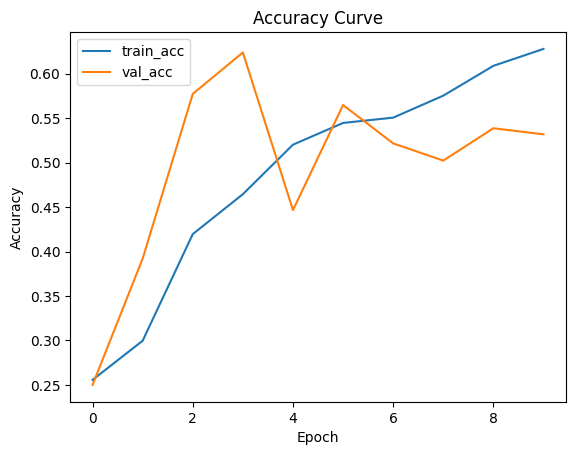

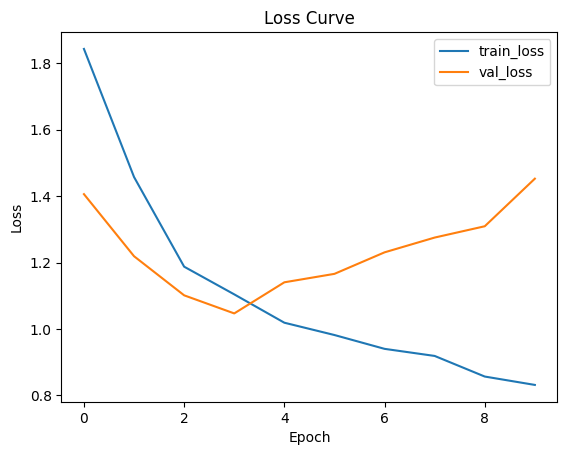

In [ ]:
# 10) Plot Training Curves
plt.figure()
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
# 11) Evaluate on Test
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")


Test Accuracy: 0.6239 | Test Loss: 1.0469


In [ ]:
# 12) Predictions
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_prob = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

In [ ]:
# 13) Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


Classification Report:
                 precision    recall  f1-score   support

    Anthracnose     0.3684    0.2864    0.3223       220
        Healthy     0.6040    0.8182    0.6950       220
           Scab     0.9694    0.4318    0.5975       220
Styler end root     0.6741    0.9591    0.7917       220

       accuracy                         0.6239       880
      macro avg     0.6540    0.6239    0.6016       880
   weighted avg     0.6540    0.6239    0.6016       880



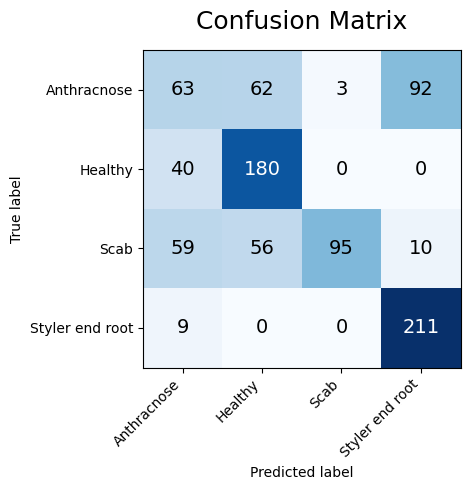

In [ ]:
# 14) Confusion Matrix (Blue style like your image, NO colorbar)
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
ax.imshow(cm, cmap=plt.cm.Blues)
ax.set_title("Confusion Matrix", fontsize=18, pad=15)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, cm[i, j],
            ha="center", va="center",
            fontsize=14,
            color="white" if cm[i, j] > thresh else "black"
        )
ax.grid(False)
plt.tight_layout()
plt.show()

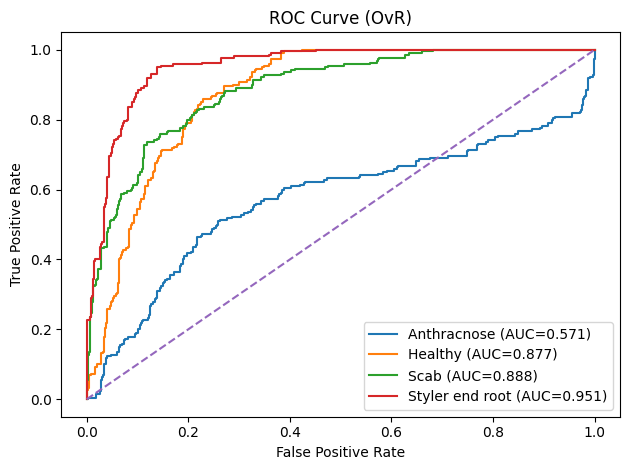

In [ ]:
# 15) ROC Curve (One-vs-Rest)
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve (OvR)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()